In [1]:
import torch
from model import mnistINR
import sys
import os

# Add the parent directory to the path so Python can find 'src'
sys.path.append(os.path.abspath(".."))
from src.tokenizer import INRTokenizer

tokenizer = INRTokenizer(sort=False, token="neuron") 

all_neurons_flat = []

for i in range(20):
    model_path = f"checkpoints/model_sample_{i}_digit_0.pth"
    
    model = mnistINR()
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    
    sd = model.state_dict()
    tokenized_model = tokenizer.tokenize(sd)
    
    for layer in tokenized_model:
        for neuron_tensor in layer:
            all_neurons_flat.append(neuron_tensor.numpy())

In [2]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

neuron_matrix = np.stack(all_neurons_flat) 
print(f"Shape of neuron matrix: {neuron_matrix.shape}") 
# neuron_matrix should be shape (N_total_neurons, Token_Dim)
# Ensure it is float32 for t-SNE
neuron_matrix = neuron_matrix.astype(np.float32)

# It is highly recommended to normalize data before t-SNE
from sklearn.preprocessing import StandardScaler
neuron_matrix_scaled = StandardScaler().fit_transform(neuron_matrix)

Shape of neuron matrix: (660, 17)


In [ ]:
# Initialize t-SNE
# perplexity: roughly the number of neighbors to consider (try 5-30)
tsne = TSNE(
    n_components=2,
    perplexity=30,      # Reduced from 30 for your smaller sample size
    early_exaggeration=10.0,
    learning_rate='auto',
    init='pca', 
    random_state=42,
    n_iter=1000
)

# Fit and transform
embeddings = tsne.fit_transform(neuron_matrix_scaled)

/home/theseeker/miniconda3/envs/neural-graphs/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


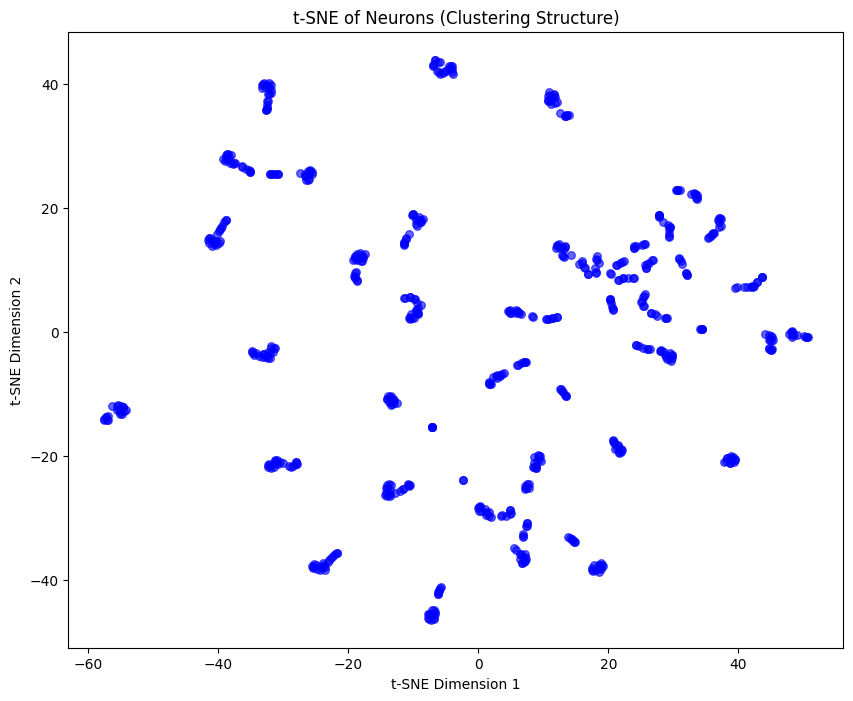

In [4]:
plt.figure(figsize=(10, 8))

# Remove c=labels and cmap. 
# You can set a fixed color like 'blue' if you want.
scatter = plt.scatter(embeddings[:, 0], embeddings[:, 1], color='blue', alpha=0.6, s=30)

plt.title("t-SNE of Neurons (Clustering Structure)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()